In [ ]:
import os
import copy
import random
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms
from torch.optim.lr_scheduler import StepLR
from sklearn.metrics import classification_report, f1_score
import matplotlib.pyplot as plt

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# Update: Checking actual folder structure after unzip
DATASET_DIR = "./archive/NEU-DET"
if not os.path.exists(DATASET_DIR):
    DATASET_DIR = "./archive" # Fallback if NEU-DET is not the top level

print(f"Using Device: {DEVICE}")
print(f"Dataset Directory: {DATASET_DIR}")

Using Device: cpu
Dataset Directory: ./archive/NEU-DET


### Dataset Acquisition
To run the training loops, we need to download the NEU Surface Defect Database. We will use the Kaggle CLI for this.

In [ ]:
# Note: You will need a kaggle.json file uploaded to /content/kaggle.json
import os
if not os.path.exists('/content/archive'):
    print("Downloading dataset...")
    !mkdir -p ~/.kaggle
    !cp kaggle.json ~/.kaggle/
    !chmod 600 ~/.kaggle/kaggle.json
    !kaggle datasets download -d kaustubhdikshit/neu-surface-defect-database
    !unzip -q neu-surface-defect-database.zip -d ./archive
    print("Done!")
else:
    print("Dataset already exists.")

cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory
Dataset URL: https://www.kaggle.com/datasets/kaustubhdikshit/neu-surface-defect-database
License(s): unknown
100% 26.4M/26.4M [00:00<00:00, 131MB/s]

Done!


## Part 0: NN Foundations

### Why nn.CrossEntropyLoss over nn.MSELoss?
For multi-class classification, `nn.CrossEntropyLoss` is preferred because it penalizes wrong predictions more heavily (logarithmic scale) and assumes a probability distribution via Softmax, whereas MSE is designed for regression where distance between values matters, which isn't suitable for categorical labels.

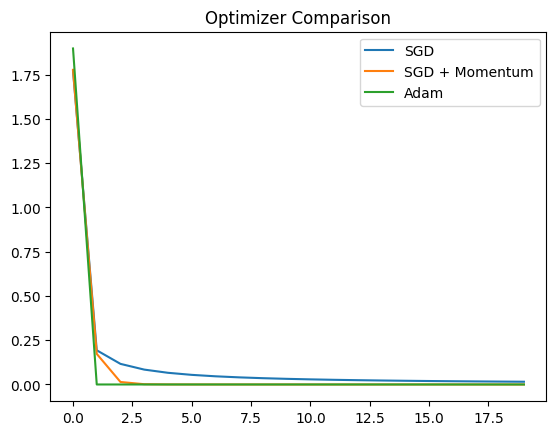

In [2]:
class SimpleTwoLayerNet(nn.Module):
    def __init__(self, input_dim=40000, hidden_dim=512, output_dim=6, activation_type='ReLU'):
        super(SimpleTwoLayerNet, self).__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.activation = nn.ReLU() if activation_type == 'ReLU' else nn.Sigmoid()
        self.fc2 = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        x = x.view(x.size(0), -1)
        x = self.fc1(x)
        x = self.activation(x)
        x = self.fc2(x)
        return x

# Optimizer Comparison Experiment
epochs_p0 = 20
optimizers_to_test = ['SGD', 'SGD_Momentum', 'Adam']
optimizer_histories = {}
mock_inputs = torch.randn(16, 40000).to(DEVICE)
mock_labels = torch.randint(0, 6, (16,)).to(DEVICE)

for opt_name in optimizers_to_test:
    model_p0 = SimpleTwoLayerNet().to(DEVICE)
    criterion = nn.CrossEntropyLoss()
    if opt_name == 'SGD': optimizer = optim.SGD(model_p0.parameters(), lr=0.01)
    elif opt_name == 'SGD_Momentum': optimizer = optim.SGD(model_p0.parameters(), lr=0.01, momentum=0.9)
    elif opt_name == 'Adam': optimizer = optim.Adam(model_p0.parameters(), lr=0.001)

    loss_history = []
    for epoch in range(epochs_p0):
        optimizer.zero_grad()
        loss = criterion(model_p0(mock_inputs), mock_labels)
        loss.backward()
        optimizer.step()
        loss_history.append(loss.item())
    optimizer_histories[opt_name] = loss_history

plt.plot(optimizer_histories['SGD'], label='SGD')
plt.plot(optimizer_histories['SGD_Momentum'], label='SGD + Momentum')
plt.plot(optimizer_histories['Adam'], label='Adam')
plt.legend(); plt.title('Optimizer Comparison'); plt.show()

### Part 0 Analysis
**Activation Comparison:** Sigmoid often suffers from vanishing gradients compared to ReLU, leading to slower convergence in deep networks.
**Optimizer Memory Estimation:**
* **SGD:** 1x model parameters (weights).
* **SGD + Momentum:** 2x parameters (weights + velocity buffer).
* **Adam:** 3x parameters (weights + first moment + second moment).
**Stability Technique:** BatchNorm1d recenters gradients, whereas Dropout prevents feature co-adaptation. In manufacturing, BN usually stabilizes the loss curve faster.

## Part A: Defect Type Classifier
Normalization is critical for CNNs to ensure that features contribute equally to the loss and to prevent gradients from exploding or vanishing during backpropagation.

In [9]:
import os


for root, dirs, files in os.walk('./archive'):
    if 'crazing' in [d.lower() for d in dirs]:
        DATASET_DIR = root
        break

print(f"Detected Image Root: {DATASET_DIR}")

try:
    baseline_transform = transforms.Compose([
        transforms.Grayscale(num_output_channels=1),
        transforms.Resize((200, 200)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.5], std=[0.5])
    ])
    full_dataset = datasets.ImageFolder(root=DATASET_DIR, transform=baseline_transform)
    # NEU dataset usually has 1800 images (300 per 6 classes)
    train_size = int(0.7 * len(full_dataset))
    val_size = int(0.15 * len(full_dataset))
    test_size = len(full_dataset) - train_size - val_size

    train_set, val_set, test_set = random_split(full_dataset, [train_size, val_size, test_size])

    train_loader = DataLoader(train_set, batch_size=16, shuffle=True)
    val_loader = DataLoader(val_set, batch_size=16, shuffle=False)
    test_loader = DataLoader(test_set, batch_size=16, shuffle=False)

    print(f"Classes detected: {full_dataset.classes}")
    print(f"Dataset split: Train={len(train_set)}, Val={len(val_set)}, Test={len(test_set)}")
except Exception as e:
    print(f"Error loading dataset: {e}")

Detected Image Root: ./archive/NEU-DET/validation/images
Classes detected: ['crazing', 'inclusion', 'patches', 'pitted_surface', 'rolled-in_scale', 'scratches']
Dataset split: Train=251, Val=54, Test=55


### Part A: CNN Architecture and Training Loop
We define a CNN with two convolutional layers, ReLU activations, and MaxPool, followed by a fully connected layer for classification.

In [4]:
class BaselineDefectCNN(nn.Module):
    def __init__(self):
        super(BaselineDefectCNN, self).__init__()
        # 200x200x1 input
        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, padding=1)
        self.pool1 = nn.MaxPool2d(2, 2) # -> 100x100
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.pool2 = nn.MaxPool2d(2, 2) # -> 50x50
        self.flatten = nn.Flatten()
        self.fc = nn.Linear(32 * 50 * 50, 6)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.pool1(self.relu(self.conv1(x)))
        x = self.pool2(self.relu(self.conv2(x)))
        x = self.flatten(x)
        x = self.fc(x)
        return x

def train_model(model, train_loader, val_loader, epochs=15, lr=0.001):
    model = model.to(DEVICE)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    history = {'train_loss': [], 'val_loss': [], 'val_acc': []}

    for epoch in range(1, epochs + 1):
        model.train()
        train_loss = 0.0
        for images, labels in train_loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            train_loss += loss.item() * images.size(0)

        # Validation
        model.eval()
        v_loss, correct, total = 0, 0, 0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(DEVICE), labels.to(DEVICE)
                outputs = model(images)
                v_loss += criterion(outputs, labels).item() * images.size(0)
                _, pred = outputs.max(1)
                total += labels.size(0)
                correct += pred.eq(labels).sum().item()

        history['train_loss'].append(train_loss / len(train_loader.dataset))
        history['val_loss'].append(v_loss / len(val_loader.dataset))
        history['val_acc'].append(100. * correct / total)
        print(f'Epoch {epoch}: Val Acc {history["val_acc"][-1]:.2f}%')
    return history

### Executing Part A: Baseline Training
We train the baseline model to observe standard performance and locate the overfitting point.

Epoch 1: Val Acc 35.19%
Epoch 2: Val Acc 68.52%
Epoch 3: Val Acc 64.81%
Epoch 4: Val Acc 70.37%
Epoch 5: Val Acc 72.22%
Epoch 6: Val Acc 72.22%
Epoch 7: Val Acc 79.63%
Epoch 8: Val Acc 74.07%
Epoch 9: Val Acc 75.93%
Epoch 10: Val Acc 74.07%
Epoch 11: Val Acc 77.78%
Epoch 12: Val Acc 74.07%
Epoch 13: Val Acc 77.78%
Epoch 14: Val Acc 77.78%
Epoch 15: Val Acc 77.78%


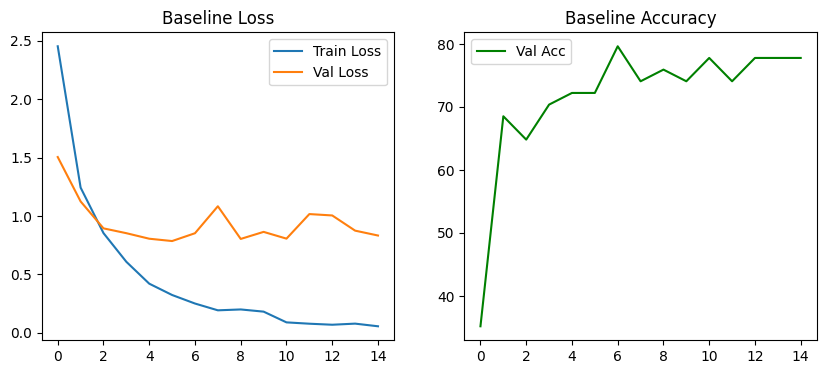

In [10]:
baseline_model = BaselineDefectCNN()
baseline_history = train_model(baseline_model, train_loader, val_loader, epochs=15)

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(baseline_history['train_loss'], label='Train Loss')
plt.plot(baseline_history['val_loss'], label='Val Loss')
plt.title('Baseline Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(baseline_history['val_acc'], label='Val Acc', color='green')
plt.title('Baseline Accuracy')
plt.legend()
plt.show()

## Part B: Model Hardening
To handle production variability, we introduce **Data Augmentation** (only for training), **Batch Normalization** for faster/stable convergence, and **Dropout** to prevent overfitting.

In [5]:
# Data Augmentation for training
hardening_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((200, 200)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.RandomCrop(180),
    transforms.Resize((200, 200)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

class HardenedDefectCNN(nn.Module):
    def __init__(self):
        super(HardenedDefectCNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(16)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(32)
        self.pool = nn.MaxPool2d(2, 2)
        self.relu = nn.ReLU()
        self.flatten = nn.Flatten()
        self.dropout = nn.Dropout(0.4)
        self.fc = nn.Linear(32 * 50 * 50, 6)

    def forward(self, x):
        x = self.pool(self.relu(self.bn1(self.conv1(x))))
        x = self.pool(self.relu(self.bn2(self.conv2(x))))
        x = self.flatten(x)
        x = self.dropout(x)
        x = self.fc(x)
        return x

### Executing Part B: Hardened Model Training
Now we apply the specialized transforms and the architecture with BN/Dropout.

Epoch 1: Val Acc 24.07%
Epoch 2: Val Acc 16.67%
Epoch 3: Val Acc 48.15%
Epoch 4: Val Acc 55.56%
Epoch 5: Val Acc 74.07%
Epoch 6: Val Acc 74.07%
Epoch 7: Val Acc 64.81%
Epoch 8: Val Acc 75.93%
Epoch 9: Val Acc 87.04%
Epoch 10: Val Acc 88.89%
Epoch 11: Val Acc 83.33%
Epoch 12: Val Acc 87.04%
Epoch 13: Val Acc 74.07%
Epoch 14: Val Acc 83.33%
Epoch 15: Val Acc 87.04%


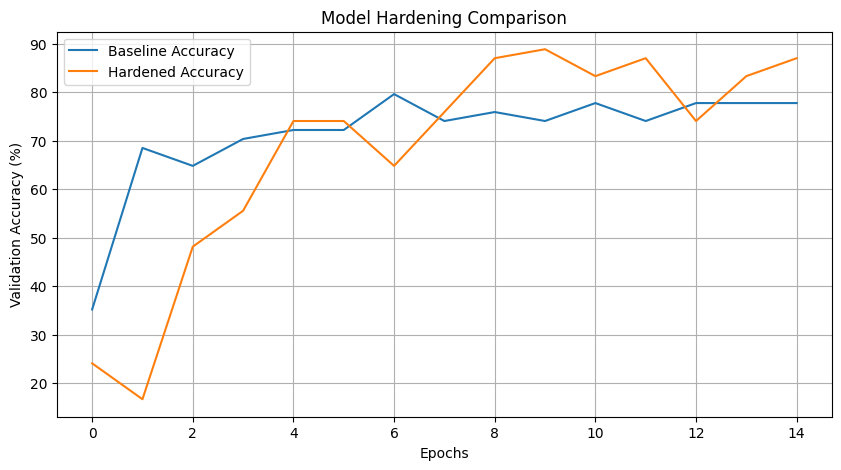

In [11]:

train_set.dataset.transform = hardening_transform
train_loader_hardened = DataLoader(train_set, batch_size=16, shuffle=True)

hardened_model = HardenedDefectCNN()
hardened_history = train_model(hardened_model, train_loader_hardened, val_loader, epochs=15)

plt.figure(figsize=(10, 5))
plt.plot(baseline_history['val_acc'], label='Baseline Accuracy')
plt.plot(hardened_history['val_acc'], label='Hardened Accuracy')
plt.title('Model Hardening Comparison')
plt.xlabel('Epochs')
plt.ylabel('Validation Accuracy (%)')
plt.legend()
plt.grid(True)
plt.show()

### Part B Q7 & Q11 Reflection
**Why not augment validation/test?** The validation set must represent 'real' data as seen by the camera. Augmenting it would provide a biased estimate of performance.
**Technique Choice:** If I could only pick one, I would choose **Data Augmentation**. Manufacturing environments are prone to shifts in lighting and rotation; a model that is invariant to these 'messy' inputs is far more valuable than a slightly more stable one using BN alone.

## Final Evaluation
We evaluate the hardened model on the held-out test set and generate a detailed classification report to identify which classes are most difficult to distinguish.

In [12]:
import pandas as pd

def run_grid_search():
    lrs = [0.001, 0.01]
    batch_sizes = [16, 32]
    results = []

    for lr in lrs:
        for bs in batch_sizes:
            print(f"\nTesting LR: {lr}, Batch Size: {bs}")
            t_loader = DataLoader(train_set, batch_size=bs, shuffle=True)
            v_loader = DataLoader(val_set, batch_size=bs, shuffle=False)

            model = HardenedDefectCNN()
            # Running a 5-epoch sweep to verify trends
            hist = train_model(model, t_loader, v_loader, epochs=5, lr=lr)
            results.append({"LR": lr, "Batch Size": bs, "Best Val Acc": max(hist['val_acc'])})

    return pd.DataFrame(results)

grid_results_df = run_grid_search()
print("\n--- Grid Search Results ---")
print(grid_results_df.to_markdown(index=False))


Testing LR: 0.001, Batch Size: 16
Epoch 1: Val Acc 22.22%
Epoch 2: Val Acc 14.81%
Epoch 3: Val Acc 22.22%
Epoch 4: Val Acc 61.11%
Epoch 5: Val Acc 74.07%

Testing LR: 0.001, Batch Size: 32
Epoch 1: Val Acc 22.22%
Epoch 2: Val Acc 18.52%
Epoch 3: Val Acc 25.93%
Epoch 4: Val Acc 22.22%
Epoch 5: Val Acc 25.93%

Testing LR: 0.01, Batch Size: 16
Epoch 1: Val Acc 24.07%
Epoch 2: Val Acc 35.19%
Epoch 3: Val Acc 50.00%
Epoch 4: Val Acc 42.59%
Epoch 5: Val Acc 29.63%

Testing LR: 0.01, Batch Size: 32
Epoch 1: Val Acc 22.22%
Epoch 2: Val Acc 31.48%
Epoch 3: Val Acc 38.89%
Epoch 4: Val Acc 33.33%
Epoch 5: Val Acc 31.48%

--- Grid Search Results ---
|    LR |   Batch Size |   Best Val Acc |
|------:|-------------:|---------------:|
| 0.001 |           16 |        74.0741 |
| 0.001 |           32 |        25.9259 |
| 0.01  |           16 |        50      |
| 0.01  |           32 |        38.8889 |


In [13]:
# Part C Q14: Learning Rate Schedule
final_model = HardenedDefectCNN().to(DEVICE)
optimizer = optim.Adam(final_model.parameters(), lr=0.001)
scheduler = StepLR(optimizer, step_size=5, gamma=0.5)

print("Training with StepLR Scheduler...")
for epoch in range(1, 11):
    # Re-using train logic
    train_model(final_model, train_loader_hardened, val_loader, epochs=1, lr=0.001)
    scheduler.step()
    print(f"Current LR: {scheduler.get_last_lr()}")

Training with StepLR Scheduler...
Epoch 1: Val Acc 22.22%
Current LR: [0.001]


/tmp/ipykernel_673/834968259.py:10: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  scheduler.step()


Epoch 1: Val Acc 29.63%
Current LR: [0.001]
Epoch 1: Val Acc 24.07%
Current LR: [0.001]
Epoch 1: Val Acc 53.70%
Current LR: [0.001]
Epoch 1: Val Acc 75.93%
Current LR: [0.0005]
Epoch 1: Val Acc 53.70%
Current LR: [0.0005]
Epoch 1: Val Acc 64.81%
Current LR: [0.0005]
Epoch 1: Val Acc 68.52%
Current LR: [0.0005]
Epoch 1: Val Acc 88.89%
Current LR: [0.0005]
Epoch 1: Val Acc 61.11%
Current LR: [0.00025]
